In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sbn
import re


In [2]:
#Import Dataframe
df = pd.read_csv('hr_project.csv')
df.sample(2)
# Remove spaces and turn everything to lower case for ease of access.
for cols in df.select_dtypes(include=["object", 'string']):
    df[cols] = df[cols].astype(str).str.strip().str.lower()
#add _ to the column names for better readability, then make lower case for ease of selection
df.columns = df.columns.str.replace(r'(?<!^)(?=[A-Z])', '_', regex=True).str.lower()
#drop duplicates
df = df.drop_duplicates()


In [113]:
title_font = {
    'fontname': 'Arial',
    'fontweight': 'bold',
    'fontsize': 14
}

def chat_labels(xlabels, ylabels, size=12, weight='bold'):
    plt.xlabel(xlabels, fontsize=size, fontweight=weight)
    plt.ylabel(ylabels,fontsize=size, fontweight=weight)

bar_color = '#0508B3'

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   age                         1470 non-null   int64
 1   attrition                   1470 non-null   str  
 2   business_travel             1470 non-null   str  
 3   daily_rate                  1470 non-null   int64
 4   department                  1470 non-null   str  
 5   distance_from_home          1470 non-null   int64
 6   education                   1470 non-null   int64
 7   education_field             1470 non-null   str  
 8   employee_count              1470 non-null   int64
 9   employee_number             1470 non-null   int64
 10  environment_satisfaction    1470 non-null   int64
 11  gender                      1470 non-null   str  
 12  hourly_rate                 1470 non-null   int64
 13  job_involvement             1470 non-null   int64
 14  job_level          

In [5]:
#Count number of records.
all_staff = df['employee_number'].nunique()
print(f'Total Record: {all_staff:,}')

Total Record: 1,470


In [6]:
#get customer churn information
attrited = df[df['attrition'] == 'yes']['employee_number'].nunique()
active_employee = all_staff - attrited
attrition_rate = round((100 * attrited) / all_staff,2)

In [7]:
#3Organise the data in a data frame
attrition_table = pd.DataFrame({
    'Details': ['Total Staff', 'Active Employees', 'Attrited', 'Attrition Rate'],
    'Values': [all_staff, active_employee, attrited, attrition_rate ]
})
display(attrition_table)

,Details,Values
0,Total Staff,1470.00
1,Active Employees,1233.00
2,Attrited,237.00
3,Attrition Rate,16.12


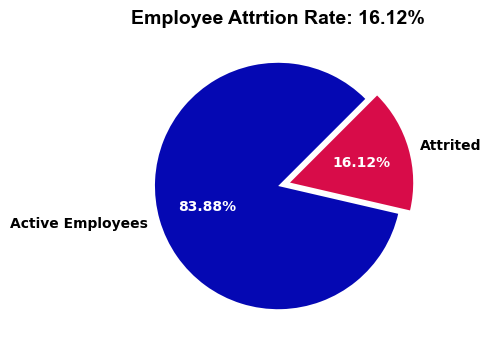

In [20]:
#Pie chat for attrition rate

plt.figure(figsize=(4,4)) #create figure and size

#Plot the pie chat
w, labels, percnts = plt.pie(attrition_table.loc[1:2, 'Values'], 
        colors=['#0508B3', "#D80C49" ], 
        explode=[0,0.1],
         labels=attrition_table.loc[1:2, 'Details'],
         startangle=45,
         autopct='%.2f%%')

#Add font weight tot he labels
for lbl in labels:
    lbl.set_fontweight('bold')

#add colors and font weight to the % values
for cents in percnts:
    cents.set_color('white')
    cents.set_fontweight('bold')

plt.title(f"Employee Attrtion Rate: {attrition_rate:,.2f}%", 
          **title_font)
plt.show()

In [9]:
#Department Exploration

#Get total department staff
depts = df.groupby('department')['employee_number'].nunique()

#Get number of atttrition
dept_attrition = (df[df['attrition'] == 'yes']
                 .groupby('department')
                 ['employee_number'].nunique())

#combine tables debt and dept attrition
dept_table = pd.concat([depts, dept_attrition], axis=1)

#Rename columns
dept_table.columns = ['Total Staff', 'Attrited']

#calculate churn rate
dept_table['Attrition Rate'] = round((100 * dept_attrition)/ depts,2)

#Reset Index
dept_table.reset_index(inplace=True)

#Clean string and columns
dept_table['department'] = dept_table['department'].str.title()
dept_table.columns = dept_table.columns.str.title()
dept_table

,Department,Total Staff,Attrited,Attrition Rate
0,Human Resources,63,12,19.05
1,Research & Development,961,133,13.84
2,Sales,446,92,20.63


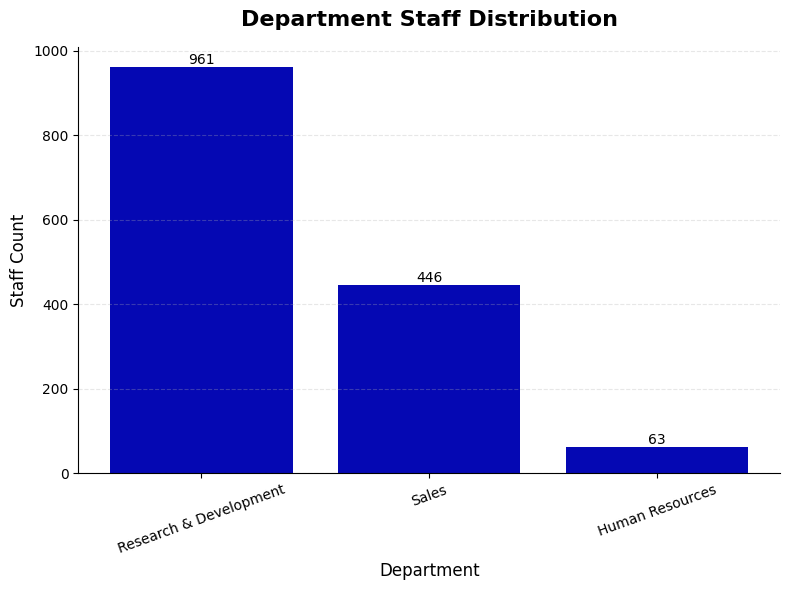

In [19]:


# Sort by total staff
dept_table = dept_table.sort_values(by='Total Staff', ascending=False)

plt.figure(figsize=(8,6))

bars = plt.bar(
    dept_table['Department'],
    dept_table['Total Staff'],
    color='#0508B3'
)

# Title and labels
plt.title(
    "Department Staff Distribution",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.ylabel('Staff Count', fontsize=12)
plt.xlabel('Department', fontsize=12)

# Clean x-axis labels (capitalize)
plt.xticks(

    rotation=20
)

# Add subtle gridlines
plt.grid(axis='y', linestyle='dashed', alpha=0.3)


# Add data labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}',
        ha='center',
        va='bottom',
        fontsize=10
    )


ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Adjust layout
plt.tight_layout()

plt.show()

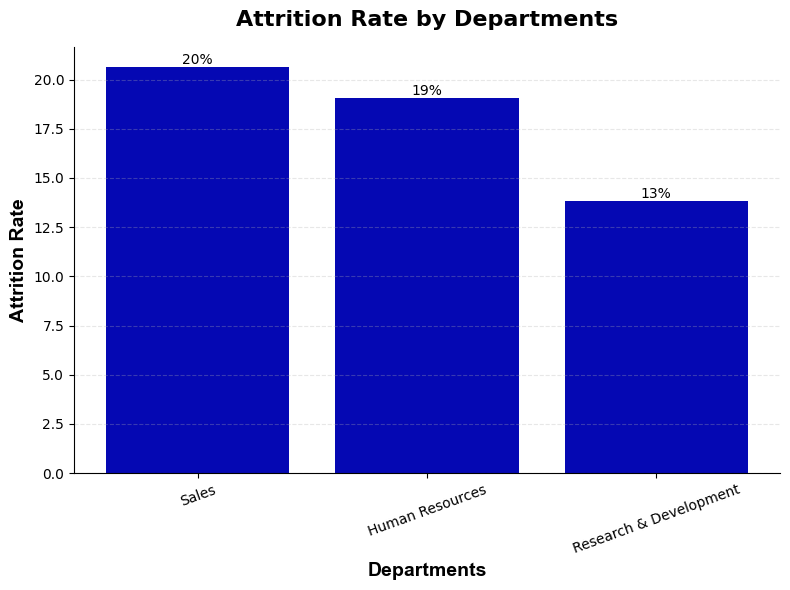

In [125]:

#Sort by Attrition rate
dept_table = dept_table.sort_values(by='Attrition Rate', ascending=False)

plt.figure(figsize=(8,6))

bars = plt.bar(
    dept_table['Department'],
    dept_table['Attrition Rate'],
    color='#0508B3'
)

# Title and labels
plt.title(
    "Attrition Rate by Departments",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.ylabel('Attrition Rate', **title_font)

plt.xlabel('Departments', **title_font)

# Clean x-axis labels (capitalize)
plt.xticks(

    rotation=20
)

# Add subtle gridlines
plt.grid(axis='y', linestyle='dashed', alpha=0.3)


# Add data labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height)}%',
        ha='center',
        va='bottom',
        fontsize=10
    )

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Adjust layout
plt.tight_layout()

plt.show()

In [12]:
# calculate number of staff who scored what in job satisfaction survey
score_one = (df[(df['job_satisfaction'] == 1)
                     & (df['attrition'] == 'yes')]
                     .groupby('department')['employee_number']).nunique()

score_two = (df[(df['job_satisfaction'] == 2)
                     & (df['attrition'] == 'yes')]
                     .groupby('department')['employee_number']).nunique()

score_three = (df[(df['job_satisfaction'] == 3)
                     & (df['attrition'] == 'yes')]
                     .groupby('department')['employee_number']).nunique()

score_four = (df[(df['job_satisfaction'] == 4)
                     & (df['attrition'] == 'yes')]
                     .groupby('department')['employee_number']).nunique()

#GEt percentages score_one_pecnt  = round((100 * score_one) / dept_attrition, 2)
score_one_pecnt  = round((100 * score_one) / dept_attrition, 2)
score_two_pecnt  = round((100 * score_two) / dept_attrition, 2)
score_three_pecnt  = round((100 * score_three) / dept_attrition, 2)
score_four_pecnt  = round((100 * score_four) / dept_attrition, 2)

# Merge table and remane columnsd
satisfaction_table = (pd.concat([dept_attrition, 
                                 score_one_pecnt,
                                  score_two_pecnt,
                                    score_three_pecnt, 
                                  score_four_pecnt], axis=1))
satisfaction_table.columns = ['Attrited', 'Poor', 'Fair', 'Good', 'Very Good']
satisfaction_table.reset_index(inplace=True)

#clean columns
satisfaction_table.columns =satisfaction_table.columns.str.title()
satisfaction_table['Department'] = satisfaction_table['Department'].str.title()
display(satisfaction_table)

,Department,Attrited,Poor,Fair,Good,Very Good
0,Human Resources,12,41.67,16.67,25.00,16.67
1,Research & Development,133,28.57,18.05,32.33,21.05
2,Sales,92,25.00,21.74,29.35,23.91


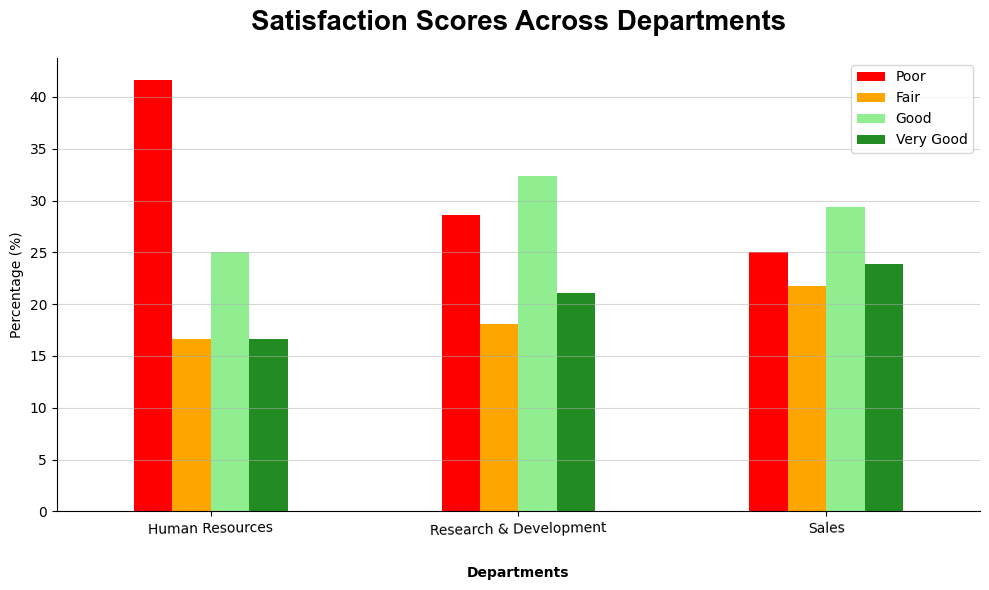

In [104]:
#Plot Satisfaction Scores Across Departments
satisfaction_table.set_index('Department')[['Poor', 'Fair', 'Good', 'Very Good']].plot(
    kind='bar',
    figsize=(10,6),
    color=['red', 'orange', 'lightgreen', 'forestgreen']
)

plt.title('Satisfaction Scores Across Departments', 
          fontsize=20,
          fontweight='bold',
          pad=20,
          fontname='Arial'
)
plt.grid(axis='y', linestyle='solid', alpha=0.5)
plt.ylabel('Percentage (%)')
plt.xlabel('Departments',fontweight='bold', labelpad=20)  
plt.xticks(rotation=1)
plt.tight_layout()
lines = plt.gca()
lines.spines['top'].set_visible(False)
lines.spines['right'].set_visible(False)
plt.show()

In [14]:
#Gender and attrition
gender_count = df.groupby('gender')['employee_number'].nunique()
gender_attrited = df[df['attrition']== 'yes'].groupby('gender')['employee_number'].nunique()
gender_table = pd.concat([gender_count, gender_attrited], axis=1)
gender_table.columns = ['Staff', 'Attrited']
gender_table['Attrition Rate'] = round((100 * gender_attrited)/gender_count, 2)
gender_table = gender_table.reset_index()


In [15]:
# gender_table.reset_index(inplace=True)
gender_table.columns = gender_table.columns.str.title()
gender_table['Gender'] = gender_table['Gender'].str.title()


In [16]:
gender_table


,Gender,Staff,Attrited,Attrition Rate
0,Female,588,87,14.80
1,Male,882,150,17.01


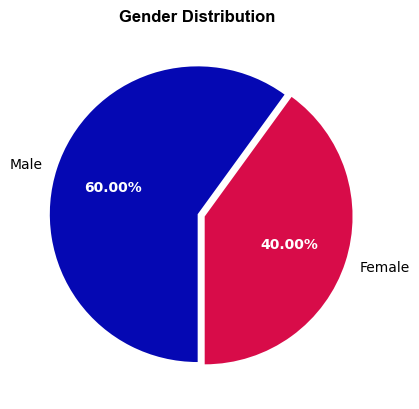

In [17]:
w, t, percents = plt.pie(gender_table['Staff'], 
        explode=[0.05,0], 
        autopct='%.2f%%', 
        labels= gender_table['Gender'],
        colors=["#D80C49","#0508B3"],
        startangle=270
        )

for cents in percents:
    cents.set_color('white')
    cents.set_fontweight('bold')

plt.title("Gender Distribution", fontname='arial', fontweight='bold')
plt.show()

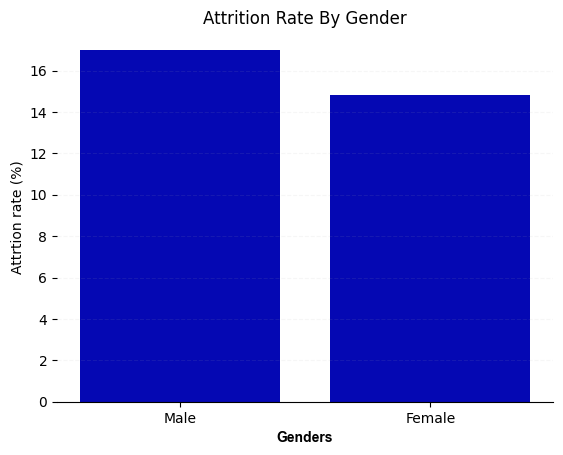

In [41]:
gender_table = gender_table.sort_values(by="Attrition Rate", ascending=False)
plt.bar(gender_table['Gender'], gender_table['Attrition Rate'], color='#0508B3')
plt.title('Attrition Rate By Gender')
plt.xlabel('Genders', fontweight='bold', fontname="Arial")
plt.ylabel('Attrtion rate (%)')
plt.grid(axis='y', linestyle='dashed', alpha=0.1)
lines = plt.gca()
lines.spines['top'].set_visible(False)
lines.spines['left'].set_visible(False)
lines.spines['right'].set_visible(False)

In [65]:
#create an age group column
df['age_group']= pd.cut (
    df['age'],
    bins = [1,26,35,44,52,60],
    labels=[
        '18-26',
        '27-35',
        '36-44',
        '45-52',
        '53-60'

    ]
)

In [93]:
#AGE GROUP SCRIPT
age_groups_vol = df.groupby('age_group')['employee_number'].nunique()

age_group_att = df[df['attrition'] == 'yes'].groupby('age_group')['employee_number'].nunique()

age_group_table = pd.concat([age_groups_vol, age_groups_vol], axis=1)

age_group_table.columns = ['Staff Count', 'Attrition']

age_group_table['Attrition Rate'] = round((100 * age_group_att)/ age_groups_vol, 2)

age_group_table = age_group_table.reset_index()

age_group_table.columns = age_group_table.columns.str.title()
age_group_table

,Age_Group,Staff Count,Attrition,Attrition Rate
0,18-26,162,162,34.57
1,27-35,567,567,18.34
2,36-44,427,427,9.60
3,45-52,208,208,11.06
4,53-60,106,106,12.26


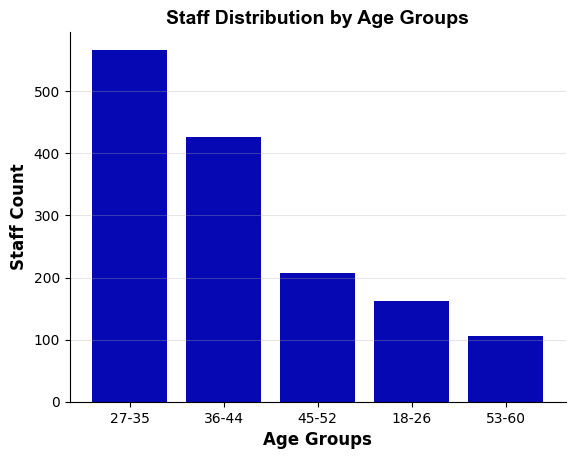

In [120]:
#Plot for age groups staff Distr
age_group_table.sort_values(by='Staff Count', ascending=False, inplace=True)
plt.bar(age_group_table['Age_Group'], age_group_table['Staff Count'], color=bar_color )
plt.title('Staff Distribution by Age Groups', **title_font)
chat_labels('Age Groups', 'Staff Count', size=12, weight='bold')
lines = plt.gca()
lines.spines['top'].set_visible(False)
lines.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='solid', alpha=0.3 )
plt.show()

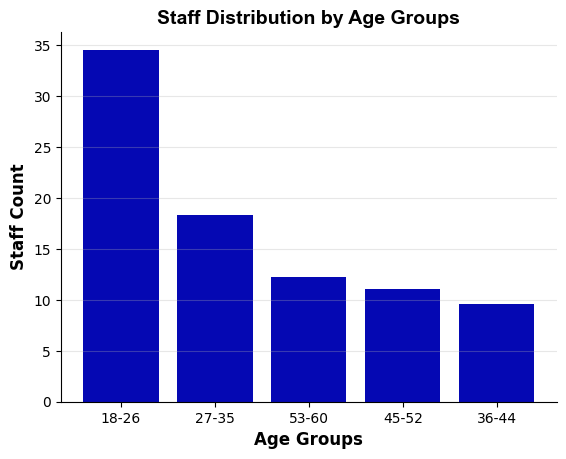

In [ ]:
#Plot for age groups and atrition

age_group_table.sort_values(by='Attrition Rate', ascending=False, inplace=True)
plt.bar(age_group_table['Age_Group'], age_group_table['Attrition Rate'], color=bar_color )
plt.title('Staff Distribution by Age Groups', **title_font)
chat_labels('Age Groups', 'Staff Count', size=12, weight='bold')
lines = plt.gca()
lines.spines['top'].set_visible(False)
lines.spines['right'].set_visible(False)
plt.grid(axis='y', linestyle='solid', alpha=0.3 )
plt.show()

In [ ]:
job_satisfaction = df.groupby('age_group')['job_satisfaction'].mean()
job_satisfaction = job_satisfaction.reset_index()
job_satisfaction['job_satisfaction'] = job_satisfaction['job_satisfaction'].apply(lambda x: round(x, 2))
job_satisfaction
Average Job satisfaction Remain the same overall

In [165]:
ms = df.groupby('marital_status')['employee_number'].nunique()


In [164]:
#attrited staff
ms_a = df[df['attrition'] == 'yes'].groupby('marital_status')['employee_number'].nunique()

,employee_number,employee_number
marital_status,,
divorced,327,33
married,673,84
single,470,120


In [176]:
a_a = round((100 * ms_a)/ ms, 2)

In [177]:
Marital_status_table = pd.concat([ms, ms_a, a_a], axis=1)

Marital_status_table.columns = [ 'Total Staff', 'Attried Staff', 'Attrition Rate']
Marital_status_table = Marital_status_table.reset_index()

In [178]:
Marital_status_table['marital_status'] = Marital_status_table['marital_status'].str.title()

In [184]:
Marital_status_table

,marital_status,Total Staff,Attried Staff,Attrition Rate
0,Divorced,327,33,10.09
1,Married,673,84,12.48
2,Single,470,120,25.53


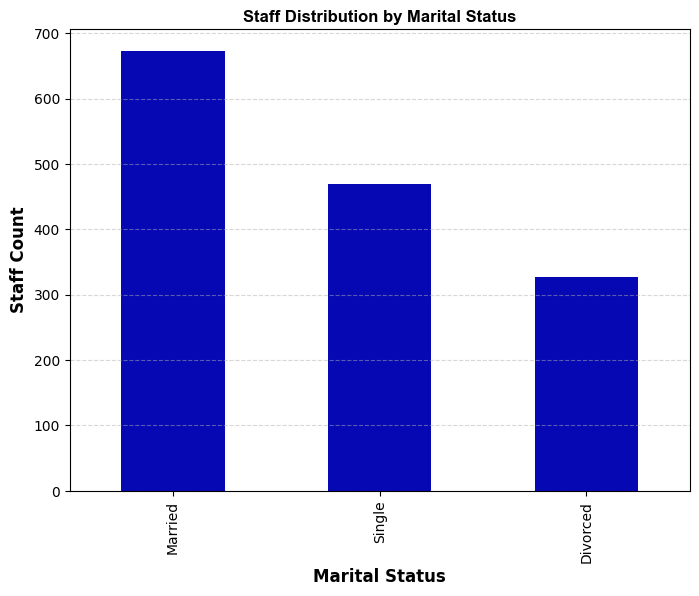

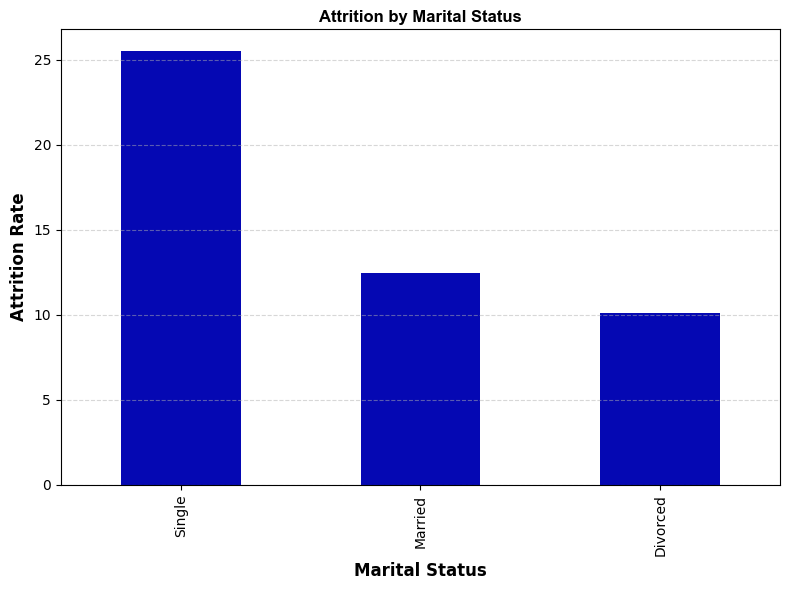

In [199]:
#Plot for marital status staff count and attrition rate

#Staff Count
Marital_status_table = Marital_status_table.sort_values(by='Total Staff', ascending=False)
Marital_status_table.set_index('marital_status')['Total Staff'].plot(
    kind='bar',
    figsize=(8,6),
    color=bar_color
    )
chat_labels('Marital Status', 'Staff Count', size=12, weight='bold')
plt.title('Staff Distribution by Marital Status', fontname="Arial", fontweight='bold', pad=5)
plt.grid(axis='y', linestyle='dashed', alpha=0.5)
plt.show()

#Attrition_rate
Marital_status_table = Marital_status_table.sort_values(by='Attrition Rate', ascending=False)
Marital_status_table.set_index('marital_status')['Attrition Rate'].plot(
    kind='bar',
    figsize=(8,6),
    color=bar_color
    )
chat_labels('Marital Status', 'Attrition Rate', size=12, weight='bold')
plt.title('Attrition by Marital Status', fontname="Arial", fontweight='bold', pad=5)
plt.grid(axis='y', linestyle='dashed', alpha=0.5)
plt.tight_layout()
plt.show()

In [239]:
# Education Field Analysis

edu_feilds = df.groupby('education_field')['employee_number'].nunique()
edu_feilds_att = df[df['attrition'] == 'yes'].groupby('education_field')['employee_number'].nunique()
edu_table = pd.concat([edu_feilds, edu_feilds_att], axis=1)
edu_table.columns = ['Total Staff', 'Attrited Staff']
edu_table['Attrition Rate'] = round((100 * edu_feilds_att) / edu_feilds, 2)
edu_table.columns =edu_table.columns.str.title()
edu_table.columns =edu_table.columns.str.title()
edu_table.reset_index(inplace=True)
edu_table['education_field'] = edu_table['education_field'].str.title()
display(edu_table)


,education_field,Total Staff,Attrited Staff,Attrition Rate
0,Human Resources,27,7,25.93
1,Life Sciences,606,89,14.69
2,Marketing,159,35,22.01
3,Medical,464,63,13.58
4,Other,82,11,13.41
5,Technical Degree,132,32,24.24


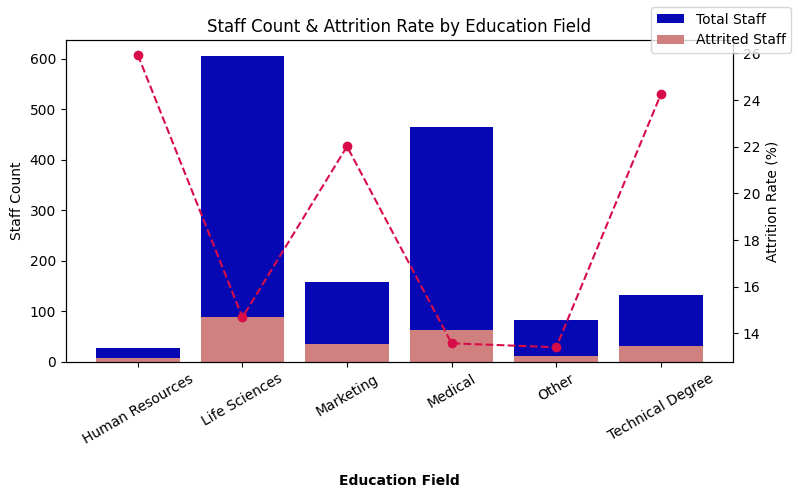

In [261]:
#plot for educational status and attrition rate
fig, ax1 = plt.subplots(figsize=(8,5))

colors = ['#0508B3', '#d18080']

ax1.bar(edu_table['education_field'],  edu_table['Total Staff'], label='Total Staff',
    color=colors[0]   
)

ax1.bar(
    edu_table['education_field'], edu_table['Attrited Staff'], 
    label='Attrited Staff', color=colors[1]  
)

ax1.set_xlabel('Education Field', labelpad=20, fontweight='bold')
ax1.set_ylabel('Staff Count')

ax2 = ax1.twinx()
ax2.plot( edu_table['education_field'], 
    edu_table['Attrition Rate'],   marker='o', linestyle='--',  color='#D80C49'
)

ax2.set_ylabel('Attrition Rate (%)')

plt.title('Staff Count & Attrition Rate by Education Field')
fig.legend(loc='upper right')
# rotate the edu fields
for label in ax1.get_xticklabels():
    label.set_rotation(30)
plt.tight_layout()
plt.show()

In [353]:
#Create a function for the attrtion tables calculation to avoid repititive codes
def attrition_tables(grouper, df=df, identity='employee_number', 
                     filter_col='attrition', filter_val='yes'):
  
  
    total_staff = df.groupby(grouper)[identity].nunique()

    attrited = (df[df[filter_col] == filter_val].
                groupby(grouper)[identity].nunique()
                )


    att_table = pd.concat([total_staff, attrited], axis= 1)


    att_table.columns = ['Total Staff', 'Attrited Staff']

    att_table['Attrition Rate'] = (((100 * att_table['Attrited Staff'])
                                    / att_table['Total Staff']).round(2))
    att_table = att_table.reset_index()
    #clean
    att_table.columns = att_table.columns.str.title()

    


    return att_table
    







In [381]:
#JOb role analysis
job_role= attrition_tables('job_role')
job_role
# job_role[Job_Role] = job_role[Job_Role].str.title()

,Job_Role,Total Staff,Attrited Staff,Attrition Rate
0,healthcare representative,131,9,6.87
1,human resources,52,12,23.08
2,laboratory technician,259,62,23.94
3,manager,102,5,4.90
4,manufacturing director,145,10,6.90
5,research director,80,2,2.50
6,research scientist,292,47,16.10
7,sales executive,326,57,17.48
8,sales representative,83,33,39.76


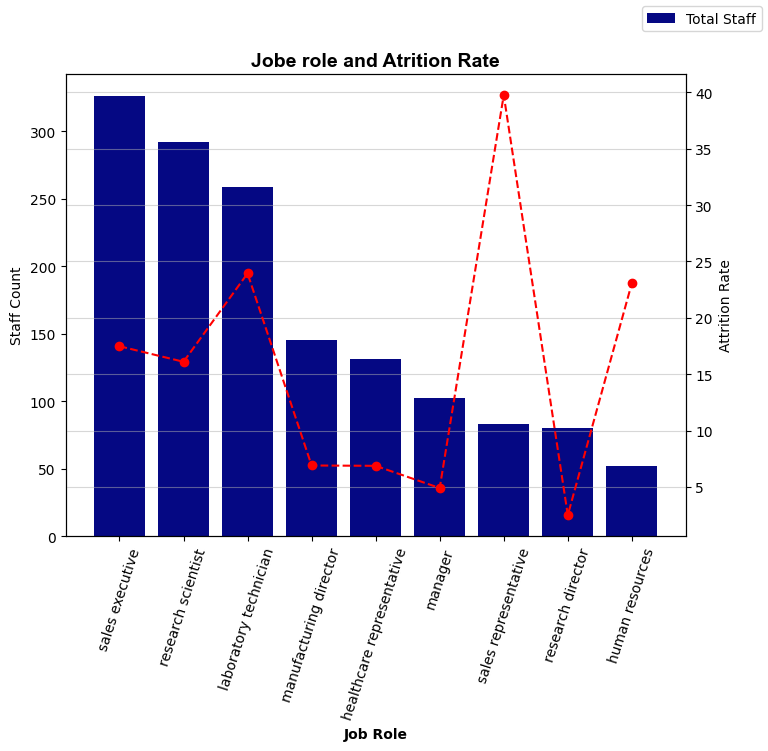

In [464]:
job_role.sort_values(by='Total Staff', ascending=False, inplace=True)
fig, mybar = plt.subplots(figsize=(8,6))

mybar.bar(job_role['Job_Role'], job_role['Total Staff'], color='#050883', label='Total Staff')
myline = mybar.twinx()
myline.plot(job_role['Job_Role'], job_role['Attrition Rate'], color='red', linestyle='dashed', marker='o')
mybar.set_xlabel("Job Role", fontweight='bold')
mybar.set_ylabel('Staff Count')
myline.set_ylabel("Attrition Rate")
fig.legend(loc='upper right')
plt.title('Jobe role and Atrition Rate', **title_font)
for roles in mybar.get_xticklabels():
    roles.set_rotation(72)
plt.grid(axis='y', linestyle='solid', alpha=0.5)
plt.show()

In [386]:
#Job role analysis
job_level = attrition_tables('job_level')
job_level

,Job_Level,Total Staff,Attrited Staff,Attrition Rate
0,1,543,143,26.34
1,2,534,52,9.74
2,3,218,32,14.68
3,4,106,5,4.72
4,5,69,5,7.25


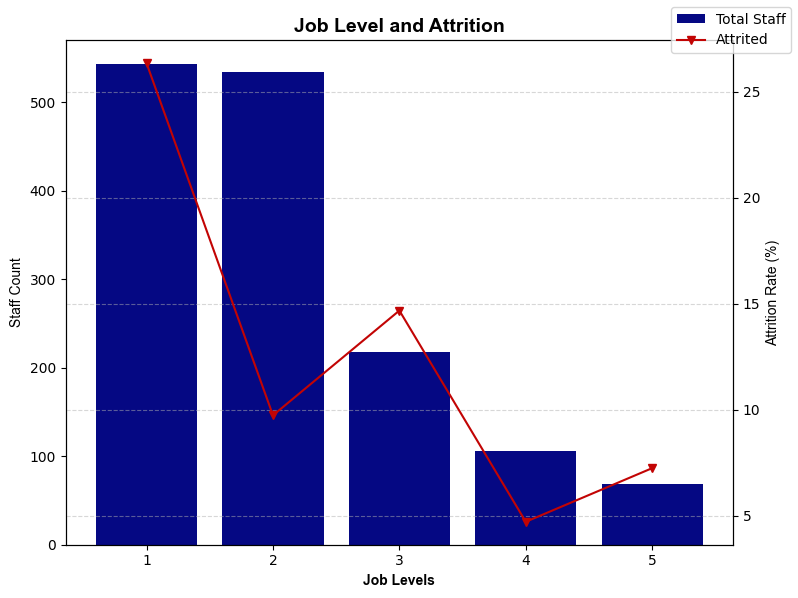

In [463]:
#plot for  Job level

fig, mybar = plt.subplots(figsize=(8,6))
mybar.bar(job_level['Job_Level'], job_level['Total Staff'], color='#050883', label='Total Staff')
myline= mybar.twinx()

myline.plot(job_level['Job_Level'],  job_level['Attrition Rate'],marker='v', color="#C20404", label='Attrited')
myline.set_ylabel('Attrition Rate (%)', fontname='Arial')
mybar.set_ylabel('Staff Count', fontname='Arial')
mybar.set_xlabel('Job Levels', fontweight='bold', fontname='Arial')
plt.grid(axis='y', linestyle='dashed', alpha=0.5)
fig.legend(loc='upper right')
plt.title('Job Level and Attrition', **title_font )
plt.tight_layout()
plt.show()


In [444]:
job_involvement = attrition_tables('job_involvement')
job_involvement = job_involvement.sort_values(by='Total Staff', ascending=False)

job_involvement

,Job_Involvement,Total Staff,Attrited Staff,Attrition Rate
2,3,868,125,14.40
1,2,375,71,18.93
3,4,144,13,9.03
0,1,83,28,33.73


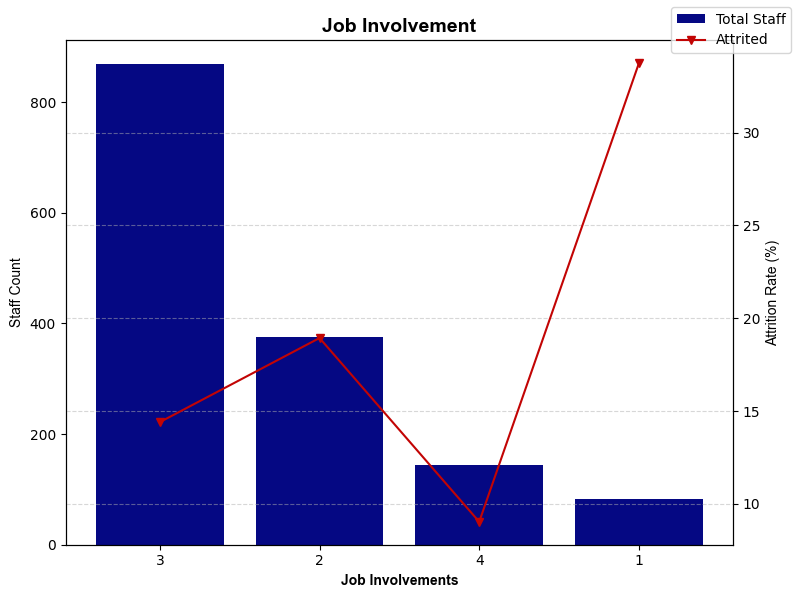

In [465]:
fig, mybar = plt.subplots(figsize=(8,6))
x_labels = job_involvement['Job_Involvement'].astype(str)
mybar.bar(x_labels, job_involvement['Total Staff'], color='#050883', label='Total Staff')
myline= mybar.twinx()

myline.plot(x_labels,  job_involvement['Attrition Rate'],marker='v', color="#C20404", label='Attrited')
myline.set_ylabel('Attrition Rate (%)', fontname='Arial')
mybar.set_ylabel('Staff Count', fontname='Arial')
mybar.set_xlabel('Job Involvements', fontweight='bold', fontname='Arial')
plt.grid(axis='y', linestyle='dashed', alpha=0.5)
fig.legend(loc='upper right')
plt.title('Job Involvement', **title_font )
plt.tight_layout()
plt.show()

In [455]:
overtime = attrition_tables('over_time')
overtime


,Over_Time,Total Staff,Attrited Staff,Attrition Rate
0,no,1054,110,10.44
1,yes,416,127,30.53


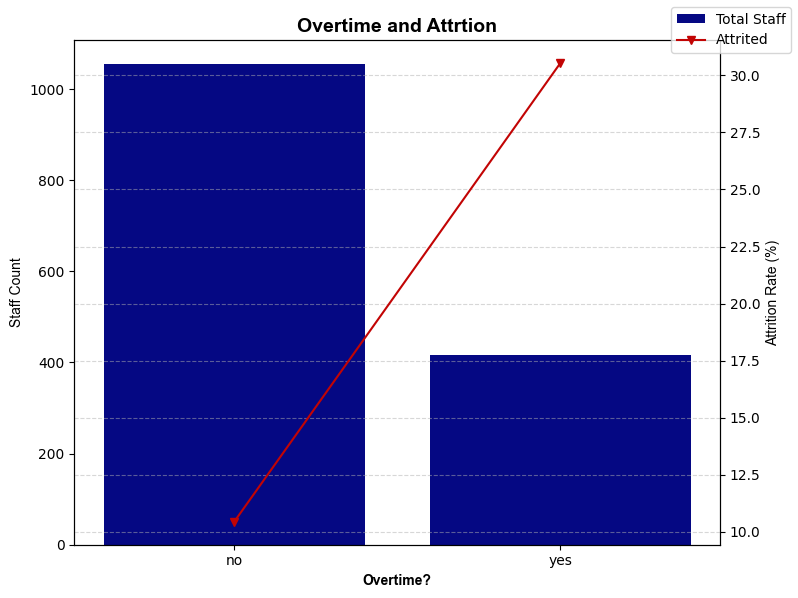

In [467]:
fig, mybar = plt.subplots(figsize=(8,6))
mybar.bar(overtime['Over_Time'], overtime['Total Staff'], color='#050883', label='Total Staff')
myline= mybar.twinx()

myline.plot(overtime['Over_Time'],  overtime['Attrition Rate'],marker='v', color="#C20404", label='Attrited')
myline.set_ylabel('Attrition Rate (%)', fontname='Arial')
mybar.set_ylabel('Staff Count', fontname='Arial')
mybar.set_xlabel('Overtime?', fontweight='bold', fontname='Arial')
plt.grid(axis='y', linestyle='dashed', alpha=0.5)
fig.legend(loc='upper right')
plt.title('Overtime and Attrtion', **title_font)
plt.tight_layout()
plt.show()

In [473]:

business_travel = attrition_tables('business_travel')
business_travel

,Business_Travel,Total Staff,Attrited Staff,Attrition Rate
0,non-travel,150,12,8.00
1,travel_frequently,277,69,24.91
2,travel_rarely,1043,156,14.96


In [ ]:
#create a fucntion for plotting line and bars
def double_plot(table_name, group_name, bar_x_label, plot_title):
    fig, mybar = plt.subplots(figsize=(8,6))
    mybar.bar(table_name[group_name], table_name['Total Staff'], color='#050883', label='Total Staff')
    myline= mybar.twinx()

    myline.plot(table_name[group_name],  table_name['Attrition Rate'],marker='v', color="#C20404", label='Attrited')
    myline.set_ylabel('Attrition Rate (%)', fontname='Arial')
    mybar.set_ylabel('Staff Count', fontname='Arial')
    mybar.set_xlabel(bar_x_label, fontweight='bold', fontname='Arial', labelpad=15)
    plt.grid(axis='y', linestyle='dashed', alpha=0.5)
    fig.legend(loc='upper right')
    plt.title(plot_title, **title_font)
    plt.tight_layout()
    plt.show()

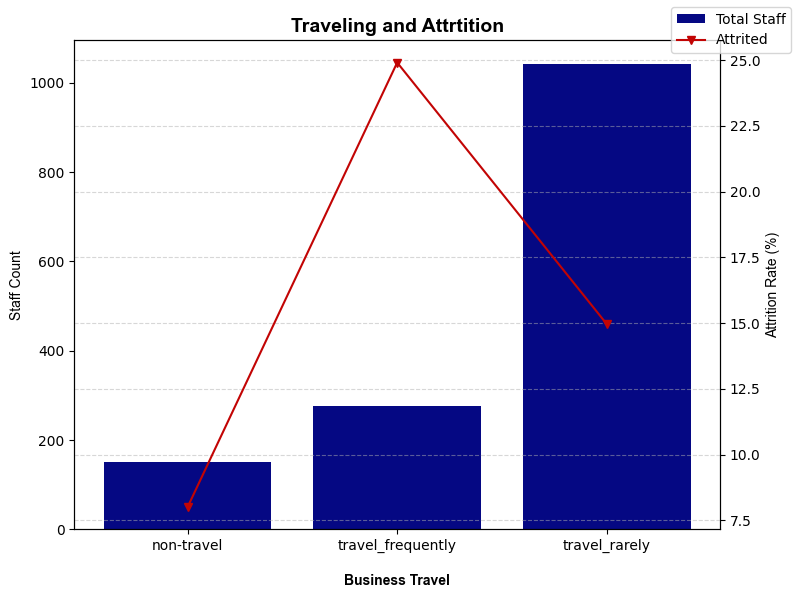

In [485]:
double_plot(business_travel, 'Business_Travel', 'Business Travel', 'Traveling and Attrtition')